# B0 — Avellaneda-Stoikov Analytical Baseline

**Purpose:** Cross-validate γ on training days (Jan 1–6); evaluate the fixed-γ A-S agent on the held-out test set (Jan 7–29).

**Design:**
- σ, A, κ are re-estimated per day from that day's data (market parameters, not preference parameters).
- γ is fixed from training-day cross-validation (Optuna TPE, n_trials ≥ 20) — never touched on test data.
- Evaluation: one trajectory per test day (seed=42), consistent with B1–B3.

**Output:** `results/b0_test_results.csv`, `results/b0_gamma_fixed.txt`

In [9]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
     if (p / "procs").exists()),
    pathlib.Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from procs.gym.experiment_config import ReplayExperimentConfig
from procs.gym.data_loader import load_multi_day
from procs.gym.calibration import calibrate_from_arrays, tune_gamma
from procs.gym.helpers.fast_rollout import fast_simulate

cfg = ReplayExperimentConfig()
cfg.ensure_artifact_dirs()
print(f"Repo root : {cfg.repo_root}")
print(f"Datasets  : {cfg.datasets_dir}")
print(f"Models    : {cfg.models_dir}")
print(f"Results   : {cfg.results_dir}")

Repo root : C:\Users\john-\Documents\Thesis_AI4T
Datasets  : C:\Users\john-\Documents\Thesis_AI4T\datasets
Models    : C:\Users\john-\Documents\Thesis_AI4T\models
Results   : C:\Users\john-\Documents\Thesis_AI4T\results


## Section 1 — Data Loading and Train/Test Split

In [10]:
TRAIN_DAYS = 6

daily_S, daily_dt, dates = load_multi_day(str(cfg.datasets_dir), pair=cfg.pair)

train_S     = daily_S[:TRAIN_DAYS]
train_dt    = daily_dt[:TRAIN_DAYS]
train_dates = dates[:TRAIN_DAYS]

test_S      = daily_S[TRAIN_DAYS:]
test_dt     = daily_dt[TRAIN_DAYS:]
test_dates  = dates[TRAIN_DAYS:]

EXPECTED_TEST_DAYS = 23
if len(train_S) != TRAIN_DAYS or len(test_S) != EXPECTED_TEST_DAYS:
    raise ValueError(
        f"Expected {TRAIN_DAYS} train days and {EXPECTED_TEST_DAYS} test days, "
        f"found {len(train_S)} and {len(test_S)}."
    )
if set(map(str, train_dates)) & set(map(str, test_dates)):
    raise ValueError("Train/test date overlap detected.")

print(f"Training days : {len(train_S)}  ({train_dates[0]} → {train_dates[-1]})")
print(f"Test days     : {len(test_S)}  ({test_dates[0]} → {test_dates[-1]})")
for d, S in zip(train_dates, train_S):
    print(f"  train {d}: {len(S):,} snapshots")

  2025-01-01:  713,815 snapshots, σ=0.000021
  2025-01-02:  766,464 snapshots, σ=0.000035
  2025-01-03:  776,383 snapshots, σ=0.000047
  2025-01-04:  778,293 snapshots, σ=0.000045
  2025-01-05:  723,494 snapshots, σ=0.000031
  2025-01-06:  766,311 snapshots, σ=0.000035
  2025-01-07:  787,093 snapshots, σ=0.000062
  2025-01-08:  821,589 snapshots, σ=0.000052
  2025-01-09:  809,421 snapshots, σ=0.000046
  2025-01-10:  789,320 snapshots, σ=0.000045
  2025-01-11:  724,826 snapshots, σ=0.000023
  2025-01-12:  719,550 snapshots, σ=0.000022
  2025-01-13:  819,981 snapshots, σ=0.000046
  2025-01-14:  775,454 snapshots, σ=0.000038
  2025-01-15:  782,299 snapshots, σ=0.000047
  2025-01-16:  788,946 snapshots, σ=0.000048
  2025-01-17:  801,259 snapshots, σ=0.000061
  2025-01-18:  829,125 snapshots, σ=0.000074
  2025-01-19:  842,892 snapshots, σ=0.000096
  2025-01-20:  857,508 snapshots, σ=0.000115
  2025-01-21:  848,107 snapshots, σ=0.000112
  2025-01-22:  812,180 snapshots, σ=0.000044
  2025-01-

## Section 2 — γ Cross-Validation on Training Days

For each training day: calibrate σ, A, κ from that day's data, then run Optuna TPE to find the
γ that maximises Sharpe ratio across 50 fast-simulate trajectories.
The final fixed γ is the mean of per-day optimal values.

In [11]:
gamma_candidates = []
train_params = []  # rows: (date, sigma, A, kappa)

for i, (S, dt, date) in enumerate(zip(train_S, train_dt, train_dates)):
    print(f"[{i+1}/{TRAIN_DAYS}] Calibrating {date} ...")
    sigma_day, A_day, kappa_day = calibrate_from_arrays(S, dt, tick_size=cfg.tick_size)
    train_params.append({"date": str(date), "sigma": sigma_day, "A": A_day, "kappa": kappa_day})
    print(f"  sigma={sigma_day:.6f}  A={A_day:.4f}  kappa={kappa_day:.0f}")

    best_gamma, _ = tune_gamma(
        S, dt,
        sigma=sigma_day, kappa=kappa_day, A=A_day,
        tick_size=cfg.tick_size,
        Q_MAX=cfg.q_max,
        gamma_range=cfg.as_gamma_range,
        n_trials=cfg.as_gamma_trials,
        num_trajectories=cfg.as_gamma_num_trajectories,
        seed=cfg.evaluation_seed,
        verbose=False,
    )
    gamma_candidates.append(best_gamma)
    print(f"  gamma_opt = {best_gamma:.4f}")

train_param_frame = pd.DataFrame(train_params).set_index("date")
sigma_train = float(train_param_frame["sigma"].median())
A_train = float(train_param_frame["A"].median())
kappa_train = float(train_param_frame["kappa"].median())
gamma_fixed = float(np.mean(gamma_candidates))

print("\nTrain-only B0 parameters used for all held-out test days:")
print(f"  gamma_fixed = {gamma_fixed:.6f}  (mean over train-day gamma optima)")
print(f"  sigma_train = {sigma_train:.6f}  (median over train days)")
print(f"  A_train     = {A_train:.4f}  (median over train days)")
print(f"  kappa_train = {kappa_train:.0f}  (median over train days)")
print(f"  per-day gamma candidates: {[f'{g:.4f}' for g in gamma_candidates]}")
display(train_param_frame)


[1/6] Calibrating 2025-01-01 ...
  σ=0.000020  A=0.2565  κ=39822
  γ_opt = 0.9751
[2/6] Calibrating 2025-01-02 ...
  σ=0.000027  A=0.2794  κ=21646
  γ_opt = 0.9848
[3/6] Calibrating 2025-01-03 ...
  σ=0.000036  A=0.2481  κ=11017
  γ_opt = 0.9933
[4/6] Calibrating 2025-01-04 ...
  σ=0.000036  A=0.1968  κ=6184
  γ_opt = 0.9226
[5/6] Calibrating 2025-01-05 ...
  σ=0.000027  A=0.1733  κ=13892
  γ_opt = 0.9778
[6/6] Calibrating 2025-01-06 ...
  σ=0.000028  A=0.2208  κ=14043
  γ_opt = 0.9972

Fixed γ for B0 (mean over 6 training days): 0.9751
  per-day γ candidates: ['0.9751', '0.9848', '0.9933', '0.9226', '0.9778', '0.9972']


In [12]:
# Save train-only B0 calibration artifacts.
gamma_path = cfg.result_path("b0_gamma_fixed.txt")
with open(gamma_path, "w") as f:
    f.write(str(gamma_fixed))

params_path = cfg.result_path("b0_train_calibration_params.csv")
train_param_frame.assign(gamma_candidate=gamma_candidates).to_csv(params_path)

print(f"Saved gamma = {gamma_fixed:.6f} -> {gamma_path}")
print(f"Saved train calibration parameters -> {params_path}")


Saved γ = 0.975143 → C:\Users\john-\Documents\Thesis_AI4T\results\b0_gamma_fixed.txt


## Section 3 — Test Evaluation (Days 7–29)

For each test day: re-estimate σ, A, κ from that day's data; apply fixed γ from training.
This mirrors realistic deployment (re-calibrate market parameters each morning, hold γ fixed).

In [13]:
rows_b0 = []

for i, (S, dt, date) in enumerate(zip(test_S, test_dt, test_dates)):
    T = float(dt.sum())

    stats = fast_simulate(
        midprices=S,
        dt_array=dt,
        gamma=gamma_fixed,
        sigma=sigma_train,
        kappa=kappa_train,
        A=A_train,
        terminal_time=T,
        tick_size=cfg.tick_size,
        Q_MAX=cfg.q_max,
        num_trajectories=cfg.evaluation_rollouts,
        seed=cfg.evaluation_seed,
        use_linear_approximation=False,
    )

    rows_b0.append({
        "Day":        str(date),
        "Sharpe":     float(stats["sharpe"].mean()),
        "Sortino":    float(stats["sortino"].mean()),
        "Max DD":     float(stats["max_drawdown"].mean()),
        "P&L-to-MAP": float(stats["pnl_to_map"].mean()),
        "Final PnL":  float(stats["total_pnl"].mean()),
        "Mean |q|": float(stats["mean_abs_q"].mean()),
        "Near Cap Fraction": float(stats.get("near_cap_fraction", np.zeros(cfg.evaluation_rollouts)).mean()),
        "Rollouts": float(cfg.evaluation_rollouts),
    })

    if (i + 1) % 5 == 0 or i == len(test_S) - 1:
        print(f"  [{i+1}/{len(test_S)}] {date}  Sharpe={rows_b0[-1]['Sharpe']:.3f}  "
              f"MaxDD={rows_b0[-1]['Max DD']:.4f}")

df_b0 = pd.DataFrame(rows_b0).set_index("Day")
print(f"\nEvaluated {len(df_b0)} test days with {cfg.evaluation_rollouts} fill rollouts per day.")

  [5/23] 2025-01-11  Sharpe=0.041  MaxDD=0.0078
  [10/23] 2025-01-16  Sharpe=0.083  MaxDD=0.0082
  [15/23] 2025-01-21  Sharpe=0.127  MaxDD=0.0164
  [20/23] 2025-01-26  Sharpe=0.026  MaxDD=0.0176
  [23/23] 2025-01-29  Sharpe=0.049  MaxDD=0.0103

Evaluated 23 test days with 20 fill rollouts per day.


## Section 4 — Results Display and Save

In [14]:
pd.set_option("display.float_format", "{:.4f}".format)

summary = pd.DataFrame({
    "Mean":   df_b0.mean(),
    "Std":    df_b0.std(),
    "Median": df_b0.median(),
}).T

print("=== B0 Per-day Test Results ===")
print(df_b0.to_string())
print("\n=== B0 Summary (mean ± std across 23 test days) ===")
print(summary.to_string())

=== B0 Per-day Test Results ===
            Sharpe  Sortino  Max DD  P&L-to-MAP  Final PnL  Mean |q|  Near Cap Fraction  Rollouts
Day                                                                                              
2025-01-07  0.0783   0.0428  0.0149      2.2528     3.0835    1.3707             0.0094   20.0000
2025-01-08  0.0928   0.0578  0.0063      2.6516     2.2956    0.8659             0.0033   20.0000
2025-01-09  0.0856   0.0490  0.0050      2.0726     1.6496    0.7963             0.0031   20.0000
2025-01-10  0.0758   0.0375  0.0062      1.4710     1.2624    0.8585             0.0037   20.0000
2025-01-11  0.0408   0.0128  0.0078      0.4595     0.4305    0.9374             0.0029   20.0000
2025-01-12  0.0439   0.0136  0.0068      0.4278     0.3858    0.9026             0.0029   20.0000
2025-01-13  0.0841   0.0451  0.0049      2.1262     1.3946    0.6561             0.0030   20.0000
2025-01-14  0.0690   0.0300  0.0066      1.2732     0.9402    0.7390             0.002

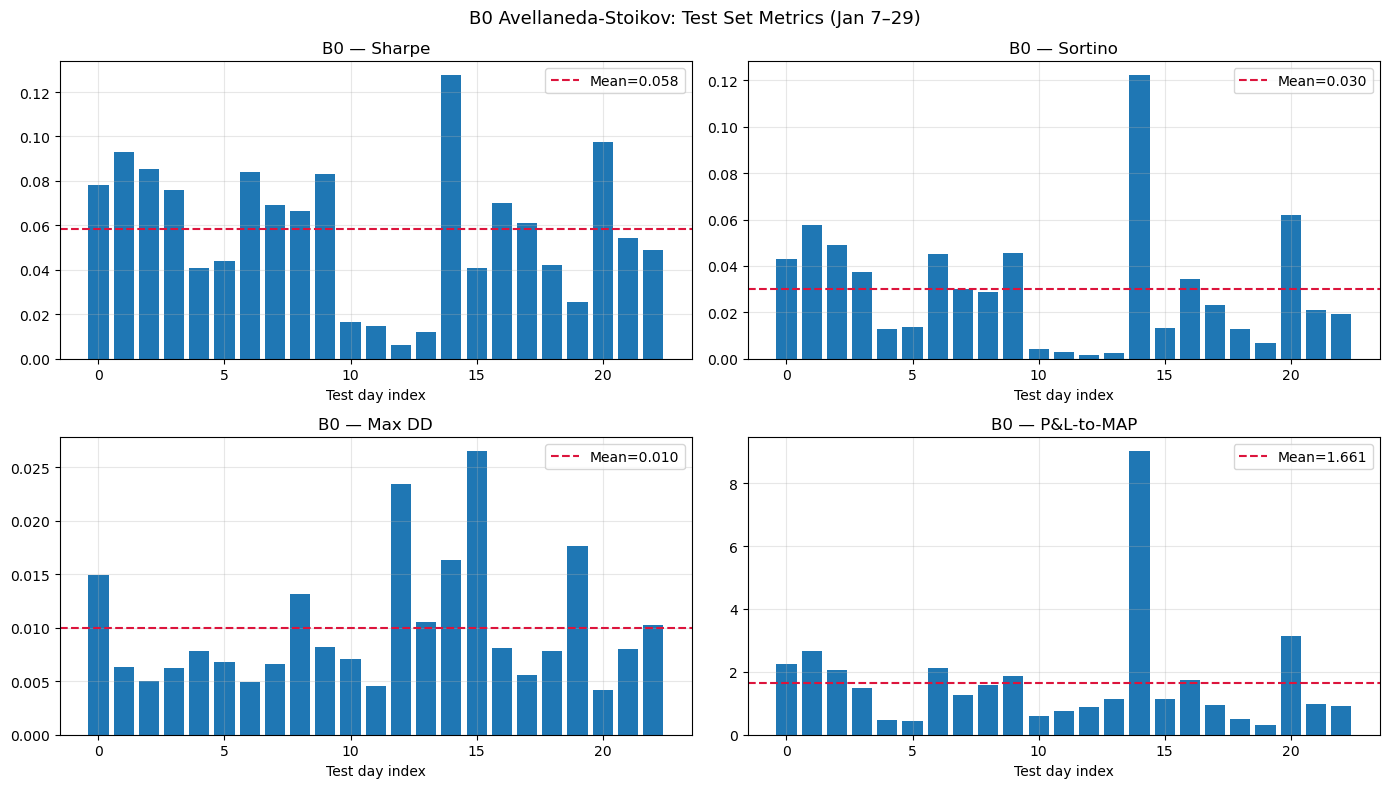

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = ["Sharpe", "Sortino", "Max DD", "P&L-to-MAP"]
for ax, metric in zip(axes.flat, metrics):
    ax.bar(range(len(df_b0)), df_b0[metric].values)
    ax.axhline(df_b0[metric].mean(), color="crimson", linestyle="--", label=f"Mean={df_b0[metric].mean():.3f}")
    ax.set_title(f"B0 — {metric}")
    ax.set_xlabel("Test day index")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("B0 Avellaneda-Stoikov: Test Set Metrics (Jan 7–29)", fontsize=13)
plt.tight_layout()
plt.savefig(str(cfg.result_path("b0_test_metrics.png")), dpi=150, bbox_inches="tight")
plt.show()

In [16]:
out_path = cfg.result_path("b0_test_results.csv")
df_b0.to_csv(out_path)
print(f"Saved → {out_path}")

Saved → C:\Users\john-\Documents\Thesis_AI4T\results\b0_test_results.csv
